# Ideal finite-wire magnetic field simulation

This notebook simulates the magnetic field of a finite straight wire above the `xy` plane in an ideal, noise-free situation IN LAB FRAME!


## Geometry
- Scan area: `200 µm × 200 µm`
- Grid step: `5 µm`
- Observation plane: `z = 0`
- Wire direction: parallel to the `x` axis
- Wire height: `10 µm`
- Wire length: `200 µm`, so it goes from one side of the square to the other
- Current: `2 mA`

## What the notebook produces
After the setup, each plot is generated in its own separate code cell:
- **a)** time traces over all pixels and the spatial average
- **b)** 2D magnetic field image in the plane
- **c)** time-position heatmap along a vertical cut at `x = 0`
- **d)** time traces at two selected points `A` and `B`
- **e)** spatial profiles at two selected times

## Physics
We model the wire as many short straight current elements and sum the magnetic field contribution from each one using the Biot–Savart law.

For a wire running along `x`, the field curls around the wire. In the scan plane, the out-of-plane component `Bz` gives a clean image-like signal, so it is used as the main simulated observable in the plots.

In [26]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True

## Setup

This cell defines the grid, the wire geometry, computes the magnetic field by direct Biot–Savart summation, and prepares the ideal time-dependent data cube used later for plots a–e.

The main displayed signal is `Bz` in `nT`.

In [27]:
mu0 = 4 * np.pi * 1e-7
I = 2e-3

L_um = 200
step_um = 5

x_um = np.arange(-L_um/2, L_um/2 + step_um, step_um)
y_um = np.arange(-L_um/2, L_um/2 + step_um, step_um)

x = x_um * 1e-6
y = y_um * 1e-6

X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)

z_wire = 10e-6

r1 = np.array([0.0, -100e-6, z_wire])
r2 = np.array([0.0,  100e-6, z_wire])

Nseg = 1000
t_wire = np.linspace(0, 1, Nseg + 1)

wire_points = r1[None, :] + (r2 - r1)[None, :] * t_wire[:, None]
seg_mid = 0.5 * (wire_points[:-1] + wire_points[1:])
dl = wire_points[1:] - wire_points[:-1]

Bx = np.zeros_like(X, dtype=float)
By = np.zeros_like(X, dtype=float)
Bz = np.zeros_like(X, dtype=float)

for i in range(Nseg):
    rx = X - seg_mid[i, 0]
    ry = Y - seg_mid[i, 1]
    rz = Z - seg_mid[i, 2]

    r_mag = np.sqrt(rx**2 + ry**2 + rz**2)
    r_mag = np.where(r_mag < 1e-15, 1e-15, r_mag)

    dlx, dly, dlz = dl[i]

    cx = dly * rz - dlz * ry
    cy = dlz * rx - dlx * rz
    cz = dlx * ry - dly * rx

    prefactor = mu0 * I / (4 * np.pi * r_mag**3)

    Bx += prefactor * cx
    By += prefactor * cy
    Bz += prefactor * cz

Bmag = np.sqrt(Bx**2 + By**2 + Bz**2)

signal_map_nT = Bz * 1e9

t_ms = np.linspace(0, 90, 181)

stimulus = np.zeros_like(t_ms)
stimulus[(t_ms >= 20) & (t_ms <= 45)] = 1.0
stimulus[(t_ms >= 50) & (t_ms <= 70)] = -1.0

Bcube_nT = np.zeros((len(t_ms), len(y_um), len(x_um)))

for k in range(len(t_ms)):
    Bcube_nT[k] = stimulus[k] * signal_map_nT

ix0 = np.argmin(np.abs(x_um - 0))

xA_um, yA_um = -30, 0
xB_um, yB_um =  30, 0

ixA = np.argmin(np.abs(x_um - xA_um))
iyA = np.argmin(np.abs(y_um - yA_um))

ixB = np.argmin(np.abs(x_um - xB_um))
iyB = np.argmin(np.abs(y_um - yB_um))

iy0 = np.argmin(np.abs(y_um - 0))

print("Point A actual [um]:", (x_um[ixA], y_um[iyA]))
print("Point B actual [um]:", (x_um[ixB], y_um[iyB]))
print("Center cut taken at y [um]:", y_um[iy0])
print("Signal at A [nT]:", signal_map_nT[iyA, ixA])
print("Signal at B [nT]:", signal_map_nT[iyB, ixB])

print("Grid shape:", X.shape)
print("Wire start [um]:", r1 * 1e6)
print("Wire end [um]:", r2 * 1e6)
print("Wire height [um]:", z_wire * 1e6)
print("Current [mA]:", I * 1e3)
print("Max |B| [uT]:", np.max(Bmag) * 1e6)
print("Bcube shape:", Bcube_nT.shape)

Point A actual [um]: (np.float64(-30.0), np.float64(0.0))
Point B actual [um]: (np.float64(30.0), np.float64(0.0))
Center cut taken at y [um]: 0.0
Signal at A [nT]: 11441.55154373764
Signal at B [nT]: -11441.55154373764
Grid shape: (41, 41)
Wire start [um]: [   0. -100.   10.]
Wire end [um]: [  0. 100.  10.]
Wire height [um]: 10.0
Current [mA]: 2.0
Max |B| [uT]: 39.80148780348542
Bcube shape: (181, 41, 41)


## Plot a) Time traces over all pixels and spatial average

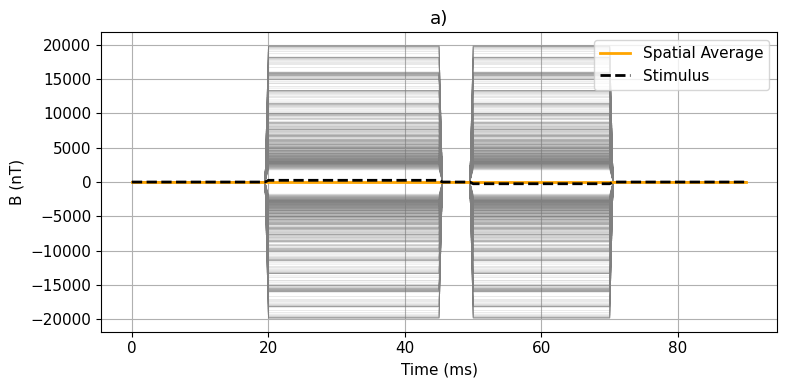

Number of traces: 1681
Spatial average min/max [nT]: -3.462680601633992e-14 3.462680601633992e-14
Stimulus scale factor used for plotting: 250


In [28]:
all_traces = Bcube_nT.reshape(len(t_ms), -1)
spatial_average = np.mean(all_traces, axis=1)

stimulus_plot = 250 * stimulus

plt.figure(figsize=(8, 4))

for i in range(all_traces.shape[1]):
    plt.plot(t_ms, all_traces[:, i], color='gray', alpha=0.12, lw=0.5)

plt.plot(t_ms, spatial_average, color='orange', lw=2, label='Spatial Average')
plt.plot(t_ms, stimulus_plot, 'k--', lw=2, label='Stimulus')

plt.xlabel('Time (ms)')
plt.ylabel('B (nT)')
plt.title('a)')
plt.legend()
plt.tight_layout()
plt.show()

print("Number of traces:", all_traces.shape[1])
print("Spatial average min/max [nT]:", np.min(spatial_average), np.max(spatial_average))
print("Stimulus scale factor used for plotting:", 250)

## Plot c) Time-position heatmap at x = 0

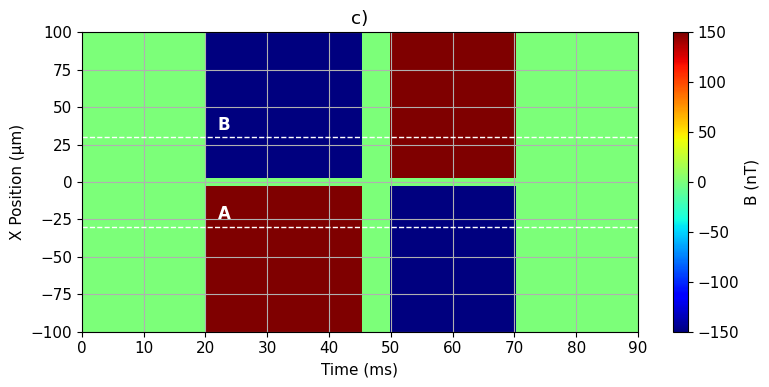

Heatmap extracted at y [um]: 0.0
Heatmap shape: (181, 41)
Heatmap min/max [nT]: -19802.951049872838 19802.951049872838


In [30]:
heatmap = Bcube_nT[:, iy0, :]

plt.figure(figsize=(8, 4))

plt.imshow(
    heatmap.T,
    extent=[t_ms.min(), t_ms.max(), x_um.min(), x_um.max()],
    origin='lower',
    aspect='auto',
    cmap='jet',
    vmin=-150,
    vmax=150
)

plt.axhline(x_um[ixA], color='white', linestyle='--', lw=1)
plt.axhline(x_um[ixB], color='white', linestyle='--', lw=1)

plt.text(22, x_um[ixA] + 5, 'A', color='white', fontsize=12, weight='bold')
plt.text(22, x_um[ixB] + 5, 'B', color='white', fontsize=12, weight='bold')

plt.xlabel('Time (ms)')
plt.ylabel('X Position (µm)')
plt.title('c)')
plt.colorbar(label='B (nT)')
plt.tight_layout()
plt.show()

print("Heatmap extracted at y [um]:", y_um[iy0])
print("Heatmap shape:", heatmap.shape)
print("Heatmap min/max [nT]:", np.min(heatmap), np.max(heatmap))

## Plot d) Time traces at points A and B

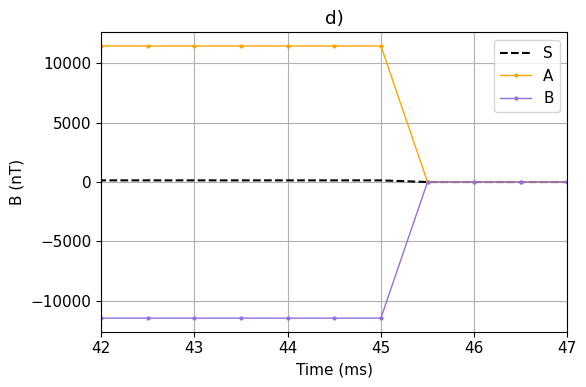

Point A [um]: (np.float64(-30.0), np.float64(0.0))
Point B [um]: (np.float64(30.0), np.float64(0.0))
Trace A min/max [nT]: -11441.55154373764 11441.55154373764
Trace B min/max [nT]: -11441.55154373764 11441.55154373764


In [31]:
trace_A = Bcube_nT[:, iyA, ixA]
trace_B = Bcube_nT[:, iyB, ixB]

stimulus_plot_small = 140 * stimulus

plt.figure(figsize=(6, 4))

plt.plot(t_ms, stimulus_plot_small, 'k--', lw=1.5, label='S')
plt.plot(t_ms, trace_A, color='orange', marker='o', markersize=2, lw=1, label='A')
plt.plot(t_ms, trace_B, color='mediumpurple', marker='o', markersize=2, lw=1, label='B')

plt.xlabel('Time (ms)')
plt.ylabel('B (nT)')
plt.title('d)')
plt.legend()
plt.xlim(42, 47)
plt.tight_layout()
plt.show()

print("Point A [um]:", (x_um[ixA], y_um[iyA]))
print("Point B [um]:", (x_um[ixB], y_um[iyB]))
print("Trace A min/max [nT]:", np.min(trace_A), np.max(trace_A))
print("Trace B min/max [nT]:", np.min(trace_B), np.max(trace_B))

## Plot e) Spatial profiles at two selected times

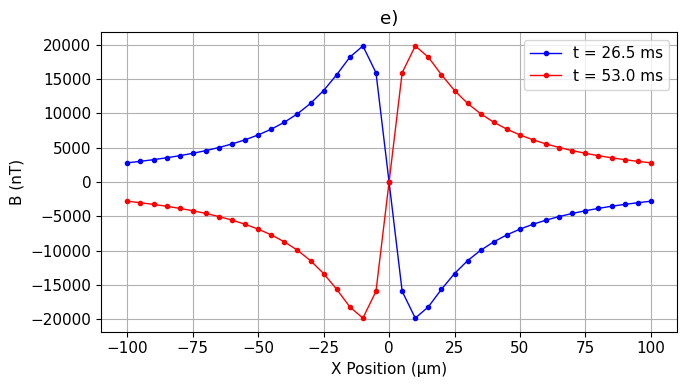

Profile time 1 [ms]: 26.5
Profile time 2 [ms]: 53.0
Profile t1 min/max [nT]: -19802.951049872838 19802.951049872838
Profile t2 min/max [nT]: -19802.951049872838 19802.951049872838


In [32]:
t1_ms = 26.6
t2_ms = 53.1

it1 = np.argmin(np.abs(t_ms - t1_ms))
it2 = np.argmin(np.abs(t_ms - t2_ms))

profile_t1 = Bcube_nT[it1, iy0, :]
profile_t2 = Bcube_nT[it2, iy0, :]

plt.figure(figsize=(7, 4))

plt.plot(x_um, profile_t1, color='blue', marker='o', markersize=3, lw=1, label=f't = {t_ms[it1]:.1f} ms')
plt.plot(x_um, profile_t2, color='red', marker='o', markersize=3, lw=1, label=f't = {t_ms[it2]:.1f} ms')

plt.xlabel('X Position (µm)')
plt.ylabel('B (nT)')
plt.title('e)')
plt.legend()
plt.tight_layout()
plt.show()

print("Profile time 1 [ms]:", t_ms[it1])
print("Profile time 2 [ms]:", t_ms[it2])
print("Profile t1 min/max [nT]:", np.min(profile_t1), np.max(profile_t1))
print("Profile t2 min/max [nT]:", np.min(profile_t2), np.max(profile_t2))